In [1]:
# Colab setup: install packages not preinstalled on Colab (safe to re-run)
!pip install -q shap

/bin/bash: pip: command not found


# Reproduce-then-Extend — Pinyon Jay Habitat Selection (Ecology)  ·  **Day 2 tutorial**

> **Published study.** Boone, J. D., Witt, C. & Ammon, E. M. (2021). "Behavior-specific occurrence patterns of Pinyon Jays."
> *PLoS ONE* (doi:10.1371/journal.pone.0237621; S1 Dataset, open). A **logistic resource-selection
> function (RSF)** — habitat *use* points (1) vs *available* points (0) on environmental predictors. Use is
> the minority class, so out-of-sample skill is scored by **AUC-PR** (area under the precision-recall curve).

## Background

Pinyon Jays are a **declining bird** of the southwestern United States, and managers need to know **which habitat they use** in order to conserve it. Daw and colleagues fit a **resource-selection function** -- a logistic regression comparing locations the jays *used* to *available* background locations -- to identify the environmental conditions associated with jay occurrence. The **primary conclusion** is that jays select particular pinyon-juniper conditions -- more open stands, sites near habitat edges, and areas with downed woody debris -- which the regression translates into a picture of suitable habitat for management.

## Data and codebook

**Unit of analysis:** a sampled ground location -- an observed jay-**use** point vs an **available**
(background) point; n = 466 (124 use).

| Variable | Definition |
|---|---|
| `use` | 1 = observed Pinyon Jay use location, 0 = available location **(outcome)** |
| `Elevation..feet.` | elevation (feet) |
| `Slope..percent.` | ground slope (%) |
| `Stand_Age..years.` | forest stand age (years) |
| `Stand_Density_Index` | stand density index (tree density / competition) |
| `Canopy_Cover..percent.` | overstory canopy cover (%) |
| `Tree_Cover..percent.` | tree cover (%) |
| `Shrub_Cover..percent.` | shrub cover (%) |
| `Forb_Cover..percent.` | forb (herbaceous) cover (%) |
| `Grass_Cover..percent.` | grass cover (%) |
| `Woody_Debris..category.1.`-`.3.` | counts of downed woody debris by size class (1-3) |
| `Distance.to.Road..km.` | distance to the nearest road (km) |
| `DisturbanceYes` | 1 if any recent disturbance was recorded at the site |
| `Distance.to.Edge..m.` | distance to the nearest habitat edge (m) |

## Descriptive results

In [2]:
# Setup: data handling, the published regression (statsmodels), and the ML learners
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm                     # regression with a full coefficient table
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score   # AUC-PR
import xgboost as xgb                             # gradient boosting
import shap                                       # exact TreeSHAP explanations

In [3]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/jays_clean.csv')
preds = [c for c in d.columns if c != 'use' and d[c].nunique() > 1]
preds = [c for c in preds if not (c.startswith('Habitat_Type') or c.startswith('Disturbance_Type'))]
X, y = d[preds].values, d['use'].values
print(f'n = {len(d)},  predictors = {len(preds)},  positives = {int(y.sum())}')
d[['use'] + preds].describe().T[['mean','std','min','max']].round(2)

n = 466,  predictors = 15,  positives = 124


,mean,std,min,max
use,0.27,0.44,0.0,1.00
Elevation..feet.,6809.96,686.14,4430.0,8700.00
Slope..percent.,28.42,17.64,0.0,91.00
Stand_Age..years.,143.20,81.17,0.0,548.00
Stand_Density_Index,154.74,97.50,0.0,542.04
Canopy_Cover..percent.,27.92,15.98,0.0,74.00
Tree_Cover..percent.,19.05,13.42,0.0,59.75
Shrub_Cover..percent.,6.07,5.98,0.0,37.25
Forb_Cover..percent.,1.57,2.60,0.0,26.00
Grass_Cover..percent.,5.75,8.77,0.0,59.75


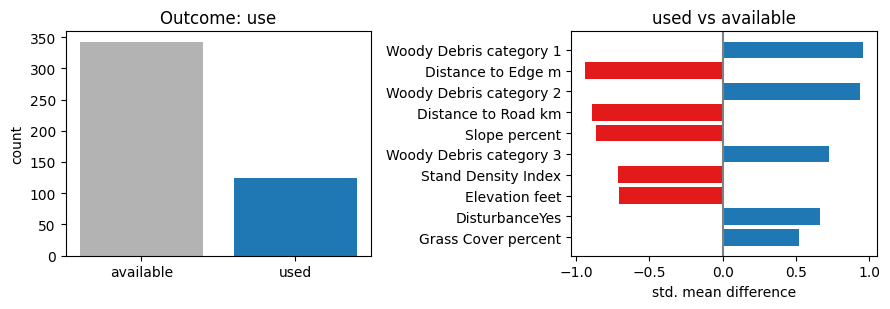

In [4]:
clean = lambda v: [s.replace('_',' ').replace('..',' ').replace('.',' ').strip() for s in v]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(['available','used'], np.bincount(y), color=['0.7','#1f78b4']); ax[0].set_title('Outcome: use'); ax[0].set_ylabel('count')
# standardized mean difference (positive - negative) per predictor
smd = pd.Series({c: (d[c][y==1].mean() - d[c][y==0].mean())/d[c].std() for c in preds})
smd = smd.reindex(smd.abs().sort_values().index)[-10:]
ax[1].barh(clean(smd.index), smd.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in smd])
ax[1].set_title('used vs available'); ax[1].set_xlabel('std. mean difference'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published RSF regression

The published model is a logistic regression of use vs availability on the environmental predictors.

In [5]:
rsf = sm.Logit(y, sm.add_constant(d[preds])).fit(disp=False)
print(rsf.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  466
Model:                          Logit   Df Residuals:                      450
Method:                           MLE   Df Model:                           15
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.6408
Time:                        12:56:42   Log-Likelihood:                -96.984
converged:                       True   LL-Null:                       -269.97
Covariance Type:            nonrobust   LLR p-value:                 1.461e-64
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         6.7349      2.827      2.382      0.017       1.194      12.276
Elevation..feet.             -0.0005      0.000     -1.080      0.280      -0.001     

**Confirmation against the published study.** The signed coefficients recover the reported habitat-selection pattern — jays select more **open** stands (negative on `Stand_Density_Index` and `Slope..percent.`) and sites **closer to edges** (negative on `Distance.to.Edge..m.`). This logistic RSF is our regression baseline.

> **A note on the model.** Boone, Witt & Ammon (2021) fit behavior-specific, multi-scale models; for this hands-on we fit one pooled resource-selection logit, which shows the same habitat-selection directions rather than identical coefficients.

We evaluate honestly: split off a **stratified 30% test set**, tune each learner's hyperparameters by cross-validation on the **training set only**, then score each model **once on the untouched test set** by AUC-PR (the right metric for this rare outcome).

In [6]:
# Honest out-of-sample evaluation: hold out a test set, tune on the training set, score once on test
from sklearn.model_selection import train_test_split
tr_idx, te_idx = train_test_split(np.arange(len(y)), test_size=0.30, stratify=y, random_state=2026)
Xtr, Xte, ytr, yte = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
test_ap = {}

# 1. logistic regression -- the published model (no hyperparameters)
lr = LogisticRegression(penalty=None, max_iter=2000).fit(Xtr, ytr)
test_ap['Logit'] = average_precision_score(yte, lr.predict_proba(Xte)[:, 1])

# 2. random forest -- max_features tuned on the TRAINING set by out-of-bag AUC-PR
best_rf = None
for mf in ['sqrt', 0.33, 0.5]:
    rf = RandomForestClassifier(n_estimators=600, max_features=mf, oob_score=True,
                                bootstrap=True, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    oob_ap = average_precision_score(ytr, rf.oob_decision_function_[:, 1])
    if best_rf is None or oob_ap > best_rf[0]: best_rf = (oob_ap, mf)
rf = RandomForestClassifier(n_estimators=600, max_features=best_rf[1], random_state=0, n_jobs=-1).fit(Xtr, ytr)
test_ap['RandomForest'] = average_precision_score(yte, rf.predict_proba(Xte)[:, 1])

# 3. XGBoost -- depth x eta tuned by xgb.cv on the TRAINING set; nrounds via early stopping
dtr = xgb.DMatrix(Xtr, label=ytr); best = None
for depth in [3, 4, 6]:
    for eta in [0.05, 0.1]:
        r = xgb.cv({'objective': 'binary:logistic', 'max_depth': depth, 'eta': eta,
                    'subsample': 0.9, 'colsample_bytree': 0.8, 'eval_metric': 'aucpr'},
                   dtr, num_boost_round=500, nfold=5, early_stopping_rounds=25, seed=0)
        s = r['test-aucpr-mean'].max()
        if best is None or s > best[0]: best = (s, depth, eta, len(r))
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': best[1], 'eta': best[2],
                 'subsample': 0.9, 'colsample_bytree': 0.8}, dtr, num_boost_round=best[3])
test_ap['XGBoost'] = average_precision_score(yte, bst.predict(xgb.DMatrix(Xte)))

print({m: round(v, 3) for m, v in test_ap.items()})
print(f"Best-ML gain over the logit on the held-out test set: "
      f"+{max(test_ap['RandomForest'], test_ap['XGBoost']) - test_ap['Logit']:.3f} AUC-PR")


{'Logit': np.float64(0.921), 'RandomForest': np.float64(0.951), 'XGBoost': np.float64(0.948)}
Best-ML gain over the logit on the held-out test set: +0.031 AUC-PR


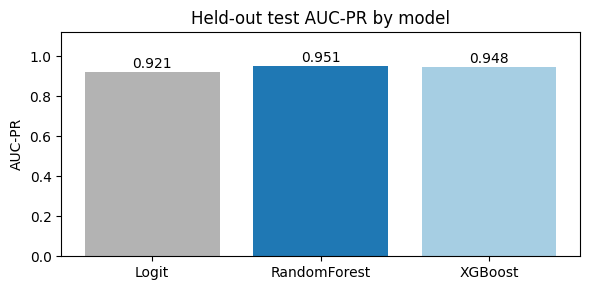

In [7]:
best_ml = 'RandomForest' if test_ap['RandomForest'] >= test_ap['XGBoost'] else 'XGBoost'
cols = ['0.7'] + ['#a6cee3'] * 2
cols[['Logit', 'RandomForest', 'XGBoost'].index(best_ml)] = '#1f78b4'
plt.figure(figsize=(6, 3)); bars = plt.bar(list(test_ap), list(test_ap.values()), color=cols)
plt.ylim(0, 1.12); plt.ylabel('AUC-PR'); plt.title('Held-out test AUC-PR by model')
for b, v in zip(bars, test_ap.values()): plt.text(b.get_x() + b.get_width() / 2, v + .02, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()


Random forest and XGBoost lift AUC-PR by roughly **+0.08** over the logistic RSF — the nonlinear,
interaction-rich structure of habitat selection that a linear-in-the-logit model cannot capture.

## Interpreting the model: importance, SHAP, and partial dependence

We open the fitted learners three ways: **permutation importance**, **SHAP values** (exact TreeSHAP — the
signed contribution of each variable to each prediction), and **partial dependence** (the shape of an effect).

In [8]:
rf = RandomForestClassifier(n_estimators=800, random_state=0, n_jobs=-1).fit(X, y)
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': 4, 'eta': 0.05,
                'subsample': 0.9, 'colsample_bytree': 0.8}, xgb.DMatrix(X, label=y), num_boost_round=300)
shap_values = shap.TreeExplainer(bst).shap_values(X)   # signed per-observation contributions (log-odds)

In [ ]:
from sklearn.inspection import permutation_importance
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
# Permutation importance (model-agnostic): shuffle each predictor and measure how far held-out
# skill drops. Fit on the training split, score on the untouched test split -- the honest version.
rf_tr = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
pim = permutation_importance(rf_tr, Xte, yte, scoring='average_precision', n_repeats=20, random_state=0, n_jobs=-1)
imp_pi = pd.Series(pim.importances_mean, index=preds).sort_values()[-8:]
ax[0].barh(clean(imp_pi.index), imp_pi.values,
           xerr=pd.Series(pim.importances_std, index=preds)[imp_pi.index].values,
           color='#33a02c', ecolor='0.6'); ax[0].set_title('Permutation importance')
ax[0].set_xlabel('drop in test AP when shuffled')
imp_sh = pd.Series(np.abs(shap_values).mean(0), index=preds).sort_values()[-8:]
ax[1].barh(clean(imp_sh.index), imp_sh.values, color='#6a3d9a'); ax[1].set_title('SHAP importance'); ax[1].set_xlabel('mean(|SHAP|)')
plt.tight_layout(); plt.show()

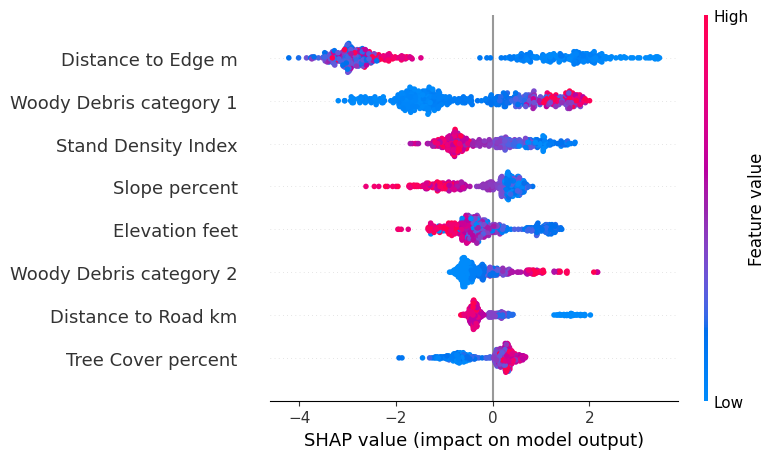

In [10]:
# SHAP summary (beeswarm): each point an observation, coloured by feature value
shap.summary_plot(shap_values, d[preds], feature_names=clean(preds), show=False, max_display=8)
plt.tight_layout(); plt.show()

**Interpreting the relationships.** The SHAP summary reads directly as habitat selection: use rises as
**stand-density index falls** (open blue points sit at positive SHAP, dense red at negative) and **closer to
edges**, with **woody debris** present. In plain terms, pinyon jays select **open pinyon–juniper woodland
near edges with downed wood** — and avoid dense, closed stands.

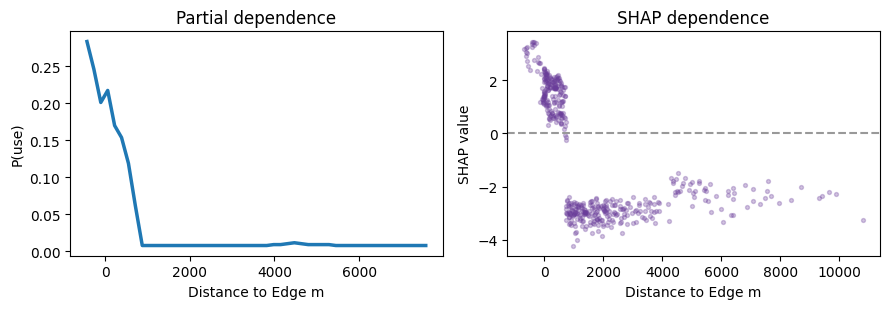

In [11]:
top1 = preds[int(np.abs(shap_values).mean(0).argmax())]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
# partial dependence: vary top1 over its range, hold others at the median
grid = np.linspace(np.quantile(d[top1], .02), np.quantile(d[top1], .98), 50)
base = np.tile(np.median(X, 0), (50, 1)); base[:, preds.index(top1)] = grid
ax[0].plot(grid, rf.predict_proba(base)[:, 1], color='#1f78b4', lw=2.5)
ax[0].set_xlabel(clean([top1])[0]); ax[0].set_ylabel('P(use)'); ax[0].set_title('Partial dependence')
# SHAP dependence: how top1's SHAP contribution varies with its value
j = preds.index(top1)
ax[1].scatter(X[:, j], shap_values[:, j], s=8, alpha=.3, color='#6a3d9a')
ax[1].axhline(0, ls='--', color='0.6'); ax[1].set_xlabel(clean([top1])[0]); ax[1].set_ylabel('SHAP value'); ax[1].set_title('SHAP dependence')
plt.tight_layout(); plt.show()

Both curves show a strongly **nonlinear** effect — the contribution turns over across the range rather than
following one logit slope, which (with the interactions SHAP captures locally) is why the learners beat the
linear RSF.

## Takeaway

Birds select habitat at nonlinear optima and via interactions — where the linear RSF struggles and trees
excel — and SHAP lets us read those relationships (open stands, edges, woody debris) directly off the fitted
model. The first of two ecology cases showing ML both predicts better *and* interprets cleanly.

## Recommended exercises

1. Vary the random-forest hyperparameters (number of trees, features per split) and report the effect on AUC-PR.
2. Generate a partial-dependence plot for a second habitat variable and describe the nonlinearity.
3. Compare RF vs XGBoost AUC-PR on the same folds; which wins, and by how much?